### `5.) EXPECTED LOSS CALCULATION`

This is the core credit risk formula used by banks.

Expected Loss (EL) = PD × LGD × EAD

PD  -> Probability borrower defaults

LGD	-> Loss severity after default

EAD -> Exposure at default (loan amount)

LOAD DATASET

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("lendingclub_features.parquet")

df.shape

(1345310, 77)

Load the MODELS

In [5]:
import joblib

logit = joblib.load("logit_model.pkl")
scaler = joblib.load("scaler.pkl")
rf_lgd = joblib.load("rf_lgd_model.pkl")

RECREATE TRAIN/TEST SPLIT

We replicate the same split used in the PD model.

In [6]:
train = df[df["issue_d"] < "2016-01-01"]
test = df[df["issue_d"] >= "2016-01-01"]

# train = loans issued before 2016
# test  = loans issued 2016–2018

Predict Probability of Default (PD) for Test Set

Reuse the PD model we trained.
Using the previously trained logistic regression model, we estimate the probability that each borrower in the test dataset will default.

The model outputs a probability value between 0 and 1, representing the estimated likelihood of default for each loan.

In [7]:
X_test = test.drop(["default","issue_d","recoveries"], axis=1)

# Handle possible infinity values from ratio features
import numpy as np
X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_test = X_test.fillna(X_test.median())

# Scale features (required for logistic regression)
X_test_scaled = scaler.transform(X_test)

# Predict PD
pd_pred = logit.predict_proba(X_test_scaled)[:,1]

test["PD"] = pd_pred

C:/Users/ALOKTP~1/AppData/Local/Temp/xpython_59196/2202905474.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["PD"] = pd_pred


Quick Check

In [8]:
test["PD"].head()

375545    0.044062
375546    0.132677
375547    0.140680
375548    0.282188
375549    0.350264
Name: PD, dtype: float64

#### Predict LGD

Using the trained Random Forest LGD model, we estimate the loss severity associated with each loan in the test dataset.

Predicted LGD values represent the proportion of loan exposure that would be lost in the event of borrower default.

In [9]:
lgd_pred = rf_lgd.predict(X_test)

# Ensure predicted LGD values remain between 0 and 1
lgd_pred = np.clip(lgd_pred, 0, 1)

test["LGD"] = lgd_pred

C:/Users/ALOKTP~1/AppData/Local/Temp/xpython_59196/1347152585.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["LGD"] = lgd_pred


Quick Check

In [10]:
test["LGD"].head()

375545    0.947720
375546    0.928932
375547    0.933269
375548    0.935297
375549    0.904792
Name: LGD, dtype: float64

#### Exposure at Default (EAD)

Exposure at Default represents the total loan exposure when a borrower defaults.

In consumer lending portfolios, the loan amount is commonly used as a proxy for EAD.

In [11]:
test["EAD"] = test["loan_amnt"]

C:/Users/ALOKTP~1/AppData/Local/Temp/xpython_59196/381692443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["EAD"] = test["loan_amnt"]


#### Expected Loss Calculation

Expected Loss represents the average credit loss anticipated for each loan.

Expected Loss = PD × LGD × EAD

In [12]:
test["expected_loss"] = test["PD"] * test["LGD"] * test["EAD"]

C:/Users/ALOKTP~1/AppData/Local/Temp/xpython_59196/256360190.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["expected_loss"] = test["PD"] * test["LGD"] * test["EAD"]


### Portfolio Expected Loss

By summing expected losses across all loans in the portfolio, we obtain the total expected loss for the lending portfolio.

In [13]:
test["expected_loss"].sum()

1330624059.2285235

Expected loss = 1.33 Billion USD

This Expected Loss is for test data i.e. all loans issued between 2016 to 2018.

#### Total Loan Portfolio (Test Dataset Period of 2016 to 2018)

In [11]:
test["loan_amnt"].sum()

7499413975.0

Total exposure (EAD) for loans from 2016 to 2018 = 7.5 Billion USD

#### Average Expected Loss per Loan

The average expected loss provides an estimate of the typical loss associated with each loan in the portfolio.

In [15]:
test["expected_loss"].mean()

2565.2760122854247

On average, each loan in the portfolio carries an expected credit loss of approximately $2,656.

#### Expected Loss Rate

Expected Loss Rate = Expected Loss / Total Exposure

In [16]:
expected_loss_total = test["expected_loss"].sum()

portfolio_exposure = test["loan_amnt"].sum()

expected_loss_rate = expected_loss_total / portfolio_exposure

print(f"Expected Loss Rate = {expected_loss_rate * 100:.2f}%")

Expected Loss Rate = 17.74%


2% to 4% Expected loss rate is realistic for unsecured consumer loans.

This relatively high loss rate is primarily driven by two characteristics of the LendingClub dataset:

- The portfolio consists of **unsecured consumer loans**, which typically exhibit **very high LGD values** due to limited recovery after borrower default. i.e. LGD predictions too close to 1 for most loans
- The observed **default probability (PD) averages around 17–18%**, which is consistent with the default rate in the filtered dataset.

So, Expected Loss Rate = EL / EAD =  PD * LD ≈ 17% * 1 = 17%
 

#### EXPECTED LOSS DISTRIBUTION

Shows how risk is distributed across loans.

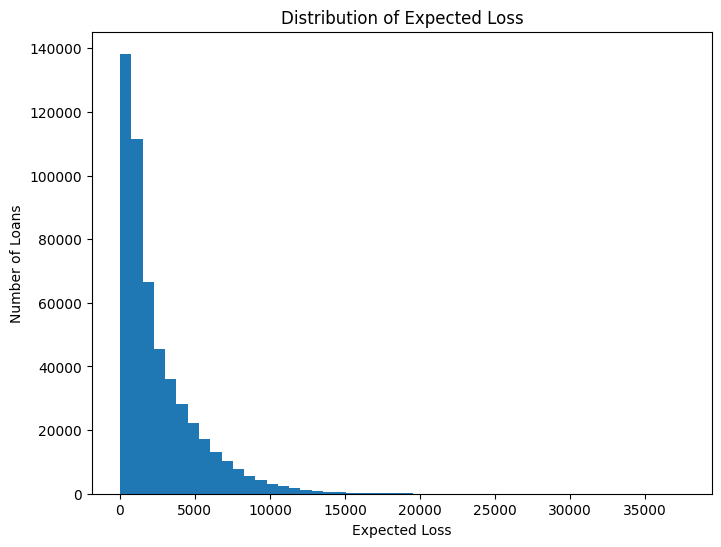

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(test["expected_loss"], bins=50)

plt.xlabel("Expected Loss")
plt.ylabel("Number of Loans")
plt.title("Distribution of Expected Loss")

plt.show()

The distribution of expected loss across loans is highly right-skewed.

Most loans carry relatively small expected losses, while a smaller number of higher-risk loans contribute disproportionately to total portfolio risk.

This pattern is typical in lending portfolios where a small segment of riskier borrowers accounts for a large share of expected credit losses.

#### EXPECTED LOSS BY CREDIT GRADE

Reconstructing Credit Grade

The original `grade` variable was converted into one-hot encoded columns during feature engineering.

Because dummy encoding removed the baseline category (Grade A), we reconstruct the grade label using the encoded grade columns for portfolio risk analysis.

In [18]:
# Recreate Grade Column

grade_cols = [c for c in test.columns if c.startswith("grade_")]

# Default to Grade A (baseline category)
test["grade"] = "A"

# Assign other grades based on dummy columns
for col in grade_cols:
    grade_letter = col.split("_")[1]
    test.loc[test[col] == 1, "grade"] = grade_letter

C:/Users/ALOKTP~1/AppData/Local/Temp/xpython_59196/1455278118.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["grade"] = "A"


In [19]:
grade_cols = [c for c in test.columns if c.startswith("grade_")]

# Default to Grade A (baseline category)
test["grade"] = "A"

# Assign other grades based on dummy columns
for col in grade_cols:
    grade_letter = col.split("_")[1]
    test.loc[test[col] == 1, "grade"] = grade_letter

C:/Users/ALOKTP~1/AppData/Local/Temp/xpython_59196/1343569639.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["grade"] = "A"


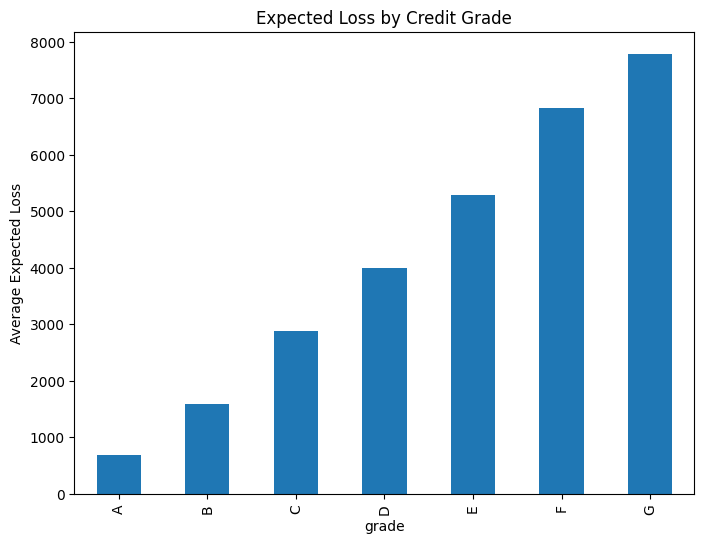

In [20]:
el_by_grade = test.groupby("grade")["expected_loss"].mean()

el_by_grade.plot(kind="bar", figsize=(8,6))

plt.ylabel("Average Expected Loss")
plt.title("Expected Loss by Credit Grade")

plt.show()

Grade A to G  are LendingClub's internal credit risk rating, adn unknown to us. So, we can't map it to any exact credit scores. However, we know:-

Grade A (highest credit grade -> lowest risk)

↓

Grade G (lowest credit grade -> highest risk)

The Expected Loss graph make sense. As Credit Grade decreases (A to G), Expected Loss increases.

### Expected Loss vs Actual Loss (Year 2016– Year 2018)

In [21]:
test["actual_loss"] = test["loan_amnt"] - test["recoveries"]

C:/Users/ALOKTP~1/AppData/Local/Temp/xpython_59196/3363956593.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["actual_loss"] = test["loan_amnt"] - test["recoveries"]


In [22]:
print(f"Actual Loss is {test['actual_loss'].sum():,.0f}")
print(f"Expected Loss is {test['expected_loss'].sum():,.0f}")

Actual Loss is 7,369,544,768
Expected Loss is 1,330,624,059


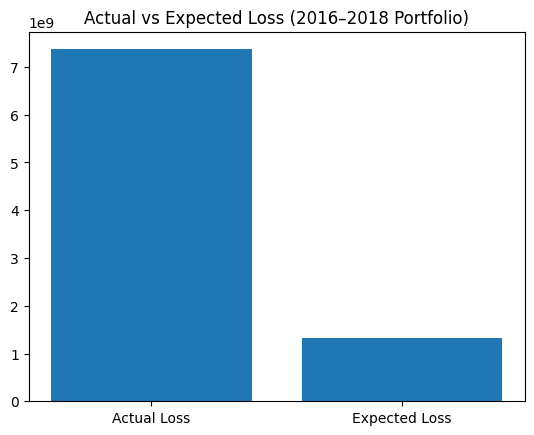

In [23]:
values = [
    test["actual_loss"].sum(),
    test["expected_loss"].sum()
]

labels = ["Actual Loss", "Expected Loss"]

plt.bar(labels, values)

plt.title("Actual vs Expected Loss (2016–2018 Portfolio)")

plt.show()

The huge gap appears because Expected Loss is forward-looking. 
It estimates average loss before defaults happen, not the realized loss after the fact.
Realized / Actual Loss might be huge as losses accumulate after many years. Actual loss also depends on borrower behaviour, economic conditions, and recovery outcomes.

Also, LGD model is trained only on defaulted loans. When applied to the full portfolio, it often underestimates extreme losses.


Model   |  	Data used

PD	    |   all loans

LGD	    |   only defaulted loans

EAD	    |    exposure at time of default


My model shows that the portfolio was riskier than predicted, which is a realistic finding in credit modelling.

Actual Loss = 7.37 Billion USD

Expected Loss = 1.33 Billion USD

My model predicted ~18% of the actual realized loss.


This difference reflects the inherent uncertainty in credit risk modelling and highlights the importance of model calibration and backtesting.

SAVE OUTPUTS TO USE IN NEXT NTEOBOOK

In [24]:
test.to_parquet("portfolio_risk_results.parquet", index=False)